In [58]:
#open file

import pandas as pd 
import numpy as np

from glob import glob

files = glob("./output/*_out.csv")

data = pd.DataFrame()

for file in files:
    frame = pd.read_csv(file, header=None)
    data = pd.concat([data, frame])

print(data.shape)


#sort into columns

model = data.iloc[:,0]
grade = data.iloc[:,1]
text = data.iloc[:,2]
prompt = data.iloc[:,3]
start_grade = data.iloc[:,4]
target_grade = data.iloc[:,5]
output_grade = data.iloc[:,6]

data.columns = ["model", "grade", "text", "prompt", "start_grade", "target_grade", "output_grade"]





(5145, 7)


In [59]:
distance_start_to_target = target_grade - start_grade

data["distance_start_to_target"] = distance_start_to_target

In [ ]:
distance_target_to_output = output_grade - target_grade

data["distance_target_to_output"] = distance_target_to_output

#qwen text 0 grade 10 prompt 6 is largest with distance 85,000 so presumably an outlier. Should check on prompts output.

data = data[data["distance_target_to_output"] < 1000]

            model  grade  text  prompt  start_grade  target_grade  \
776    gemma4:e4b     10     0       6        10.07            10   
776    mistral:7b     10     0       6        10.07            10   
776  qwen2.5:0.5b     10     0       6        10.07            10   
776      phi4:14b     10     0       6        10.07            10   
776   llama3.1:8b     10     0       6        10.07            10   

     output_grade  distance_start_to_target  distance_target_to_output  
776          9.36                     -0.07                      -0.64  
776          9.89                     -0.07                      -0.11  
776      85192.88                     -0.07                   85182.88  
776          8.88                     -0.07                      -1.12  
776          9.06                     -0.07                      -0.94  


In [61]:
data["text_and_grade_identifier"] = data["grade"].astype(str) + data["text"].astype(str)

In [62]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * distance_start_to_target * C(model)",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())


                                   Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             distance_target_to_output
No. Observations:              5144                Method:                         REML                     
No. Groups:                    21                  Scale:                          4.3068                   
Min. group size:               244                 Log-Likelihood:                 -11178.7003              
Max. group size:               245                 Converged:                      Yes                      
Mean group size:               245.0                                                                        
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


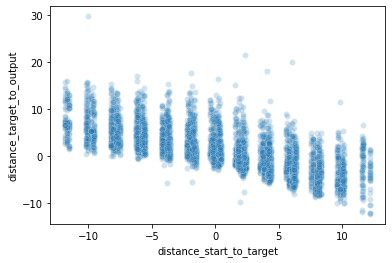

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=data,
    x="distance_start_to_target",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

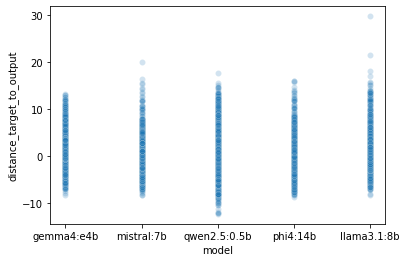

In [64]:
sns.scatterplot(
    data=data,
    x="model",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

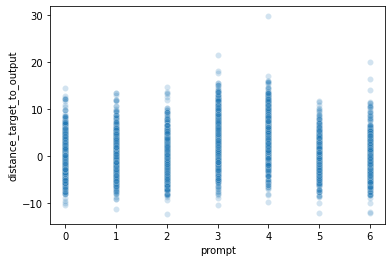

In [65]:
sns.scatterplot(
    data=data,
    x="prompt",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

In [66]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * distance_start_to_target * C(model)",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

                                   Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             distance_target_to_output
No. Observations:              5144                Method:                         REML                     
No. Groups:                    21                  Scale:                          4.3068                   
Min. group size:               244                 Log-Likelihood:                 -11178.7003              
Max. group size:               245                 Converged:                      Yes                      
Mean group size:               245.0                                                                        
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [67]:
data.loc[data["distance_target_to_output"].idxmax()]



,model,grade,text,prompt,start_grade,target_grade,output_grade,distance_start_to_target,distance_target_to_output,text_and_grade_identifier
739,gemma4:e4b,10,0,4,10.07,0,8.82,-10.07,8.82,100
739,mistral:7b,10,0,4,10.07,0,9.78,-10.07,9.78,100
739,qwen2.5:0.5b,10,0,4,10.07,0,12.89,-10.07,12.89,100
739,phi4:14b,10,0,4,10.07,0,6.67,-10.07,6.67,100
739,llama3.1:8b,10,0,4,10.07,0,29.79,-10.07,29.79,100


In [68]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * C(model) + distance_start_to_target",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

                       Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     distance_target_to_output
No. Observations:     5144        Method:                 REML                     
No. Groups:           21          Scale:                  5.3634                   
Min. group size:      244         Log-Likelihood:         -11668.2741              
Max. group size:      245         Converged:              Yes                      
Mean group size:      245.0                                                        
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                0.197    0.284   0.694 0.487 -0.359  0.753
C(prompt)[T.1]                          -0.569    0.270  -2.106 0.035 -1.098 -0.039
C(prompt)[T.2] 

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))
